In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt

Text(0.5, 1.0, 'Wigner function')

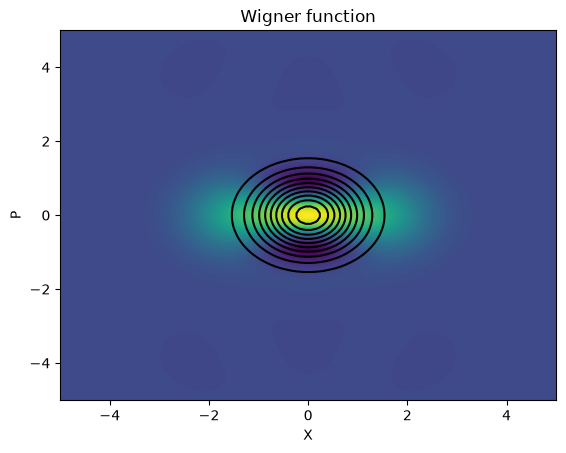

In [ ]:
#coherent state from qutip
alpha = 1
N = 10
coherent_state = qt.coherent(N, alpha) + qt.coherent(N, -alpha)
fock_state = qt.fock(N, 0)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner = qt.wigner(coherent_state, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
fock_wigner = qt.wigner(fock_state, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), coherent_wigner, 100)
ax.contour(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), fock_wigner, 10, colors='k')
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')

Visualizing the overlap of quadrature measurements of two coherent states

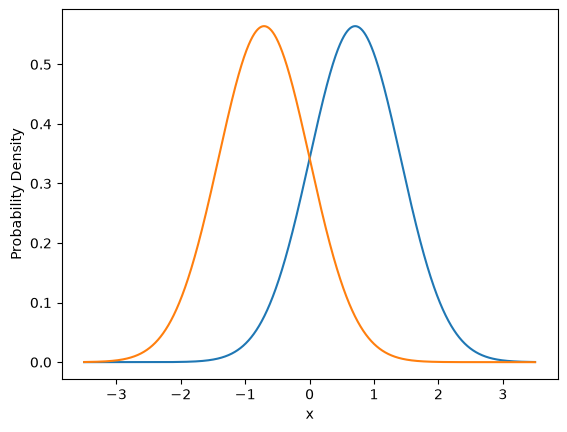

In [ ]:
#coherent state from qutip
alpha = 0.5
N = 100
size = 10000
axis_size = alpha*3+2
coherent_state = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
xvec = np.linspace(-axis_size, axis_size, size)
wf = qt.distributions.HarmonicOscillatorWaveFunction(coherent_state, extent=[-axis_size, axis_size], steps=size)
wf2 = qt.distributions.HarmonicOscillatorWaveFunction(coherent_state2, extent=[-axis_size, axis_size], steps=size)
xvec, wvec2 = wf.xvecs[0], wf2.xvecs[0]
psi_x, psi_x2 = wf.data, wf2.data
probabilities = np.abs(psi_x)**2
probabilities2 = np.abs(psi_x2)**2

plt.plot(xvec, probabilities, label='Coherent State')
plt.plot(xvec, probabilities2, label='Coherent State (Conjugate)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.show()

Visualizing the overlap of two coherent states with displacement and measurement in the photon number basis

Text(0.5, 1.0, 'Photon Number Distributions for Coherent States')

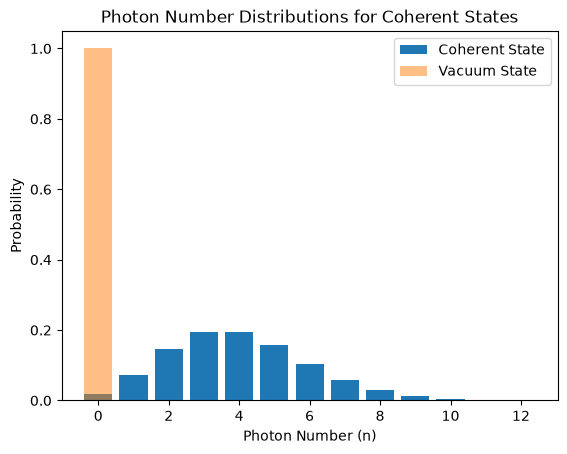

In [40]:
#coherent state from qutip
alpha = 1
N = int((alpha*1.7+2)**2)
size = N
axis_size = alpha*3+2
coherent_state = qt.coherent(N, 2*alpha)
coherent_state2 = qt.coherent(N, 0)
xvec = np.linspace(-axis_size, axis_size, size)
nvec = np.arange(N)
probabilities = np.abs(coherent_state.full().flatten())**2
probabilities2 = np.abs(coherent_state2.full().flatten())**2


plt.bar(nvec[:size], probabilities, width=0.8, label='Coherent State')
plt.bar(nvec[:size], probabilities2, width=0.8, label='Vacuum State',alpha=0.5)
plt.xlabel('Photon Number (n)')
plt.ylabel('Probability')
plt.legend()
plt.title('Photon Number Distributions for Coherent States')

## Guessing Criteria:

### Best Guess Criterion:

Always give the best guess of either 0 or 1 for a given measurement. Error rate $P_e = P(0)P(1|0) + P(1)(0|1)

### Decision with Inconclusive Results: (P(Null)) We don't do tihs yet but we will later

Mode A: Unambigious State Discrimination, $P_e = 0$ highly unpractical for us at times

Mode B: Error-erasure compromise. Can have all 3 where P(Null) is simply an erasure

Below I calculate for the theoretical vlaues with the mathematics behind it:

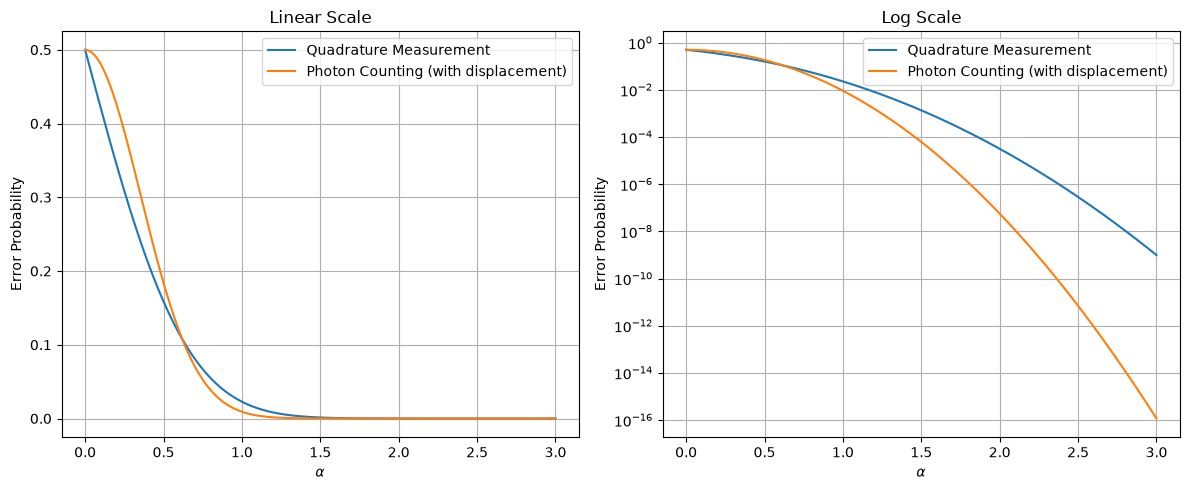

In [50]:
def best_guess_quadrature(alpha, N): #For best guess criterion
    p_error = 0.5 * (1.0 - sp.special.erf(np.sqrt(2) * alpha))
    return p_error
def best_guess_photon_count(alpha, N):
    p_error = 0.5 * np.exp(-4 * alpha**2)
    return p_error

alphas = np.linspace(0, 3, 200)
p_errors_quad = [best_guess_quadrature(a, N=100) for a in alphas]
p_errors_photon = [best_guess_photon_count(a, N=100) for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale plot
ax1.plot(alphas, p_errors_quad, label='Quadrature Measurement')
ax1.plot(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel('Error Probability')
ax1.set_title('Linear Scale')
ax1.legend()
ax1.grid(True)

# Log scale plot
ax2.semilogy(alphas, p_errors_quad, label='Quadrature Measurement')
ax2.semilogy(alphas, p_errors_photon, label='Photon Counting (with displacement)')
ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel('Error Probability')
ax2.set_title('Log Scale')
ax2.legend()
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()

Here I will now use Qutip to calculate psuedo-experimental results which should be verified by the graphs above.